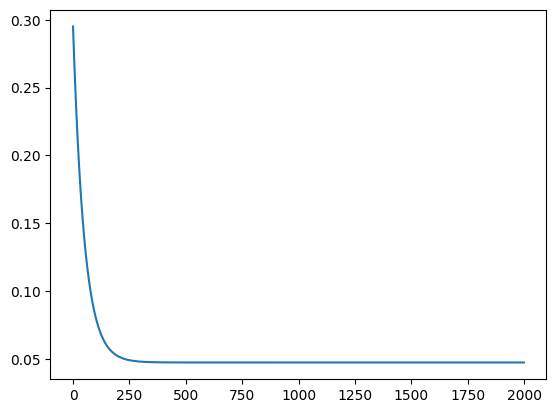

In [3]:
import numpy as np
import matplotlib.pyplot as plt
file=np.loadtxt('ex2data1.txt',delimiter=',')
x=file[:,0:2]
y=file[:,2]
def normalize(x):
    avg=np.mean(x,axis=0)
    std=np.std(x,axis=0)
    x=(x-avg)/std
    return x
x=normalize(x)
m=len(x[:,0])
x_b=np.c_[np.ones(m),x[:,0],x[:,1]]
theta=np.zeros(3)
alpha=0.01
iteration=2000
def compute_cost(x,y,theta):
    errors=x@theta-y
    return (1/(2*m))*np.dot(errors,errors)
def gradient_decent(x,y,theta,alpha,iteration):
    cost_history=[]
    for _ in range(iteration):
        gradient=(1/m)*(x.T)@(x@theta-y)
        theta=theta-gradient*alpha
        cost_history.append(compute_cost(x_b,y,theta))
    return theta,cost_history

theta,cost=gradient_decent(x_b,y,theta,alpha,iteration)
iterations=[i for i in range(iteration)]
plt.plot(iterations,cost)
plt.show()

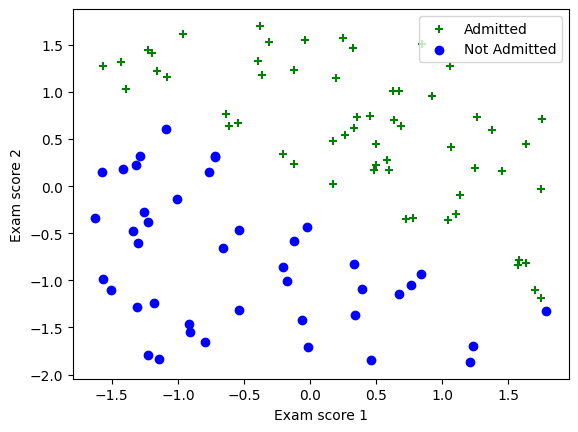

[ 0.68069018  9.58234016 13.75881077]


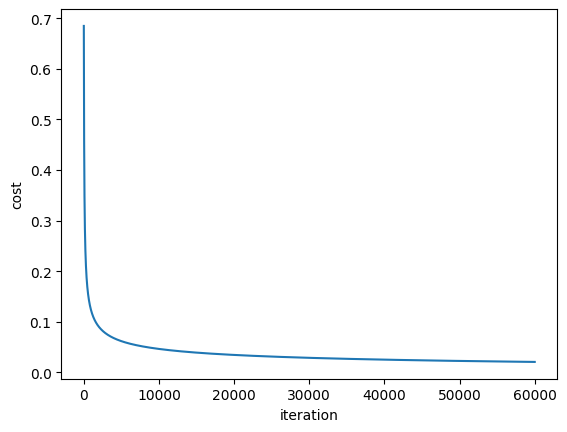

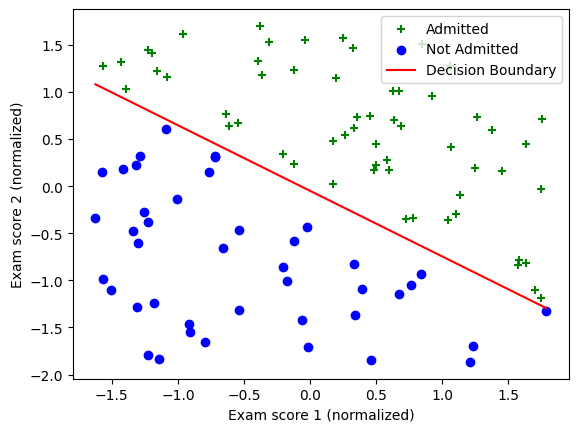

In [4]:
np.random.seed(0) 
exam1=np.random.uniform(30,100,100)
exam2=np.random.uniform(30,100,100)
y=((0.4*exam1+exam2*0.6)>65).astype(float)

x=np.column_stack((exam1,exam2))
x_no_bias = np.column_stack((exam1, exam2))
mu = np.mean(x_no_bias, axis=0)
sigma = np.std(x_no_bias, axis=0)
x = (x_no_bias - mu)/sigma
def plot_data(x,y):
    pos1=y==1
    pos2=y==0
    plt.scatter(x[pos1][:,0],x[pos1][:,1],c='g',marker='+',label='Admitted')
    plt.scatter(x[pos2][:,0],x[pos2][:,1],c='b',marker='o',label='Not Admitted')
    plt.xlabel('Exam score 1')
    plt.ylabel('Exam score 2')
    plt.legend()
    plt.show()
plot_data(x,y)
theta=np.zeros(3)
alpha=0.05
iteration=60000
def sigmoid(z):
    return 1/(1+np.exp(-z))
def compute_cost(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon =0
    cost = (-y @ np.log(h+epsilon) - (1 - y) @ np.log(1 - h+epsilon)) / m
    return cost
# 5. Gradient Descent
def gradient_decent(X, y, theta, alpha, iteration):
    m = len(y)
    cost_history = []

    for i in range(iteration):
        h = sigmoid(X @ theta)
        gradient = (X.T @ (h - y)) / m
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history
x=np.column_stack((np.ones(100),x))

theta,cost=gradient_decent(x,y,theta,alpha,iteration)
iterations=[i for i in range(iteration)]
print(theta)

plt.plot(iterations,cost)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.show()
plt.scatter(x[y==1,1], x[y==1,2], c='g', marker='+', label='Admitted')
plt.scatter(x[y==0,1], x[y==0,2], c='b', marker='o', label='Not Admitted')

x1_vals = np.linspace(x[:,1].min(), x[:,1].max(), 100)

x2_vals = -(theta[0] + theta[1]*x1_vals) / theta[2]

plt.plot(x1_vals, x2_vals, 'r-', label='Decision Boundary')
plt.xlabel('Exam score 1 (normalized)')
plt.ylabel('Exam score 2 (normalized)')
plt.legend()
plt.show()

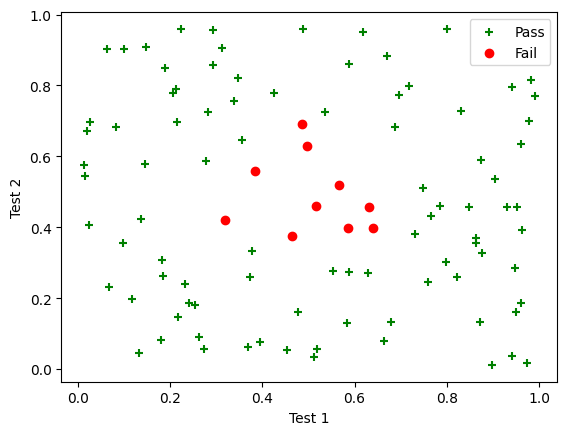

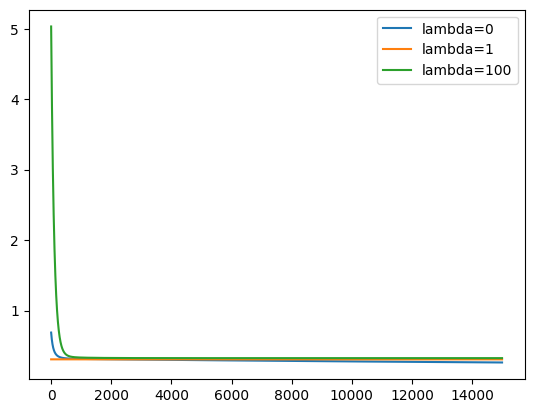

In [5]:
test1=np.random.uniform(0,1,100)
test2=np.random.uniform(0,1,100)
y=((test1-0.5)**2+(test2-0.5)**2>0.2**2).astype(float)
#x=np.cloumn_stack((test1,test2))
x = np.column_stack((test1, test2))

def sigmoid(z):
    return 1/(1+np.exp(-z))
def compute_cost(x,y,theta,lamda):
    h=sigmoid(x@theta)
    cost=(-y@np.log(h)-(1-y)@np.log(1-h))/100
    reg=lamda*np.dot(theta[1:],theta[1:])/(200)
    return cost+reg
def gradient_decent(x,y,theta,alpha,lamda,iteration):
    m=len(y)
    cost=[]
    for _ in range(iteration):
        h=sigmoid(x@theta)
        gradient=(x.T@(h-y))/100
        gradient[1:]+=(lamda/200)*theta[1:]
        theta=theta-alpha*gradient
        cost.append(compute_cost(x,y,theta,lamda))  
    return theta,cost
def plot_data(X, y):
    plt.scatter(X[y==1,0], X[y==1,1], c='g', marker='+', label='Pass')
    plt.scatter(X[y==0,0], X[y==0,1], c='r', marker='o', label='Fail')
    plt.xlabel('Test 1')
    plt.ylabel('Test 2')
    plt.legend()
    plt.show()

plot_data(x, y)
def map_feature(x1,x2):
    m = len(x1)
    out = np.ones((m, 1))  
    for i in range(7):
        for j in range(i+1):
           new= x1**(i-j)*x2**(j)
           out=np.column_stack((out,new))
    return out
x_mapped=map_feature(x[:,0],x[:,1])
theta=np.zeros(x_mapped.shape[1])
lamdas=[0,1,100]
theta_list=[]
iteration=15000
alpha=0.01
for lambd in lamdas:
    theta,cost=gradient_decent(x_mapped,y,theta,alpha,lambd,iteration)
    # theta_list=theta_list.append(theta)
    plt.plot(cost,label=f"lambda={lambd}")
plt.legend()
plt.show()
# 5. Plot decision boundary

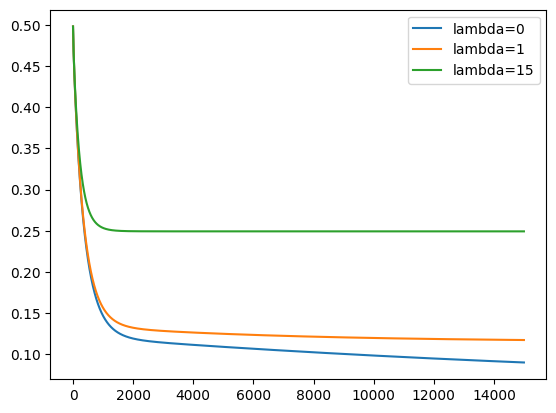

[]

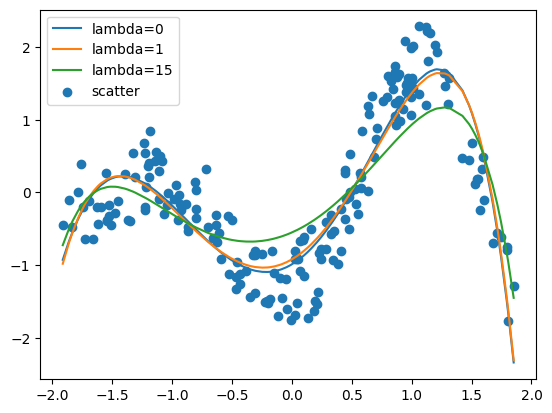

In [50]:
x1=np.random.uniform(0,10,200)
y=x1*np.sin(x1)+np.random.uniform(0,5,200)
x1=(x1-np.mean(x1))/np.std(x1)
y=(y-np.mean(y))/np.std(y)

def compute_cost(x,y,theta,lamda):
    m = len(x1)
    h=(x@theta)-y
    cost=np.dot(h,h)/(2*m)
    reg=lamda*np.dot(theta[1:],theta[1:])/(2*m)
    return cost+reg
def gradient_decent(x,y,theta,alpha,lamda,iteration):
    m=len(y)
    cost=[]
    for _ in range(iteration):
        h=x@theta
        gradient=(x.T@(h-y))/m
        gradient[1:]+=(lamda/m)*theta[1:]
        theta=theta-alpha*gradient
        cost.append(compute_cost(x,y,theta,lamda))  
    return theta,cost

def map_feature(x1):
    m = len(x1)
    out = np.ones((m, 1))  
    for i in range(1,7):
        new= x1**i
        out=np.column_stack((out,new))
    return out
x_mapped=map_feature(x1)
x_mapped[:,1:] = (x_mapped[:,1:] - np.mean(x_mapped[:,1:], axis=0)) / np.std(x_mapped[:,1:], axis=0)
theta=np.zeros(x_mapped.shape[1])
lamdas=[0,1,15]
theta_list=[]
iteration=15000
alpha=0.01
for lambd in lamdas:
    theta = np.zeros(x_mapped.shape[1])  
    theta,cost=gradient_decent(x_mapped,y,theta,alpha,lambd,iteration)
    theta_list.append(theta)

    plt.plot(cost,label=f"lambda={lambd}")
plt.legend()
plt.show()
idx = np.argsort(x1)

for i,lambd in enumerate(lamdas):
    theta=theta_list[i]
    plt.plot(x1[idx],(x_mapped @ theta_list[i])[idx],label=f"lambda={lambd}")

plt.scatter(x1,y,label='scatter')
plt.legend()
plt.plot()

In [62]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(x_mapped,y,test_size=0.3,random_state=42)
theta_train,cost_train=gradient_decent(x_train,y_train,theta,alpha,lambd,iteration)
y_train_pred=x_train@theta_train
y_test=x_val@theta_train
train_mse=np.mean((y_train_pred-y_train)**2)
test_mse=np.mean((y_val-y_test)**2)
print("Training MSE:", train_mse)
print("Validation MSE:", test_mse)

Training MSE: 0.7350371785321038
Validation MSE: 0.7632614520899409
